# DPT Pruning Visualization on Rapid-Motion Frames

**Purpose:** Provide visual evidence for Reviewer 2 Comment 5 — demonstrate that DPT correctly prunes blurry/rapid-motion frames, and that GAT's self-attention preserves overall classification.

**Three-panel figure:**
1. **Frame sequence strip:** Thumbnails of consecutive frames; rapid-motion/blurry frames highlighted with red borders
2. **Similarity matrix heatmap:** Inter-frame cosine similarity; blurry frames appear as dark rows/cols
3. **DPT-pruned graph:** Most frames connected; isolated/weakly-connected (blurry) frames marked in red

**Configuration:**
- Raw frame path: `D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_01\Original\`
- Frame range: 87235 to 87265 (31 frames)
- Features NPZ: `Feature_P01_01_DEFT_S1.npz`
- DPT percentile: 95

**Estimated runtime:** ~2-3 min.

## 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from matplotlib.gridspec import GridSpec

print('Imports done.')

Imports done.


## 2. Configuration

In [2]:
# === USER CONFIGURATION ===
RAW_FRAME_DIR  = r"D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_01\P01_01"
INPUT_NPZ      = "../../Features/Features_DEFT_S1/Feature_P01_01_DEFT_S1.npz"

FRAME_START    = 87235
FRAME_END      = 87264
DPT_PERCENTILE = 95

# Blurry-frame detection threshold (lower mean-similarity = more blurry)
# Frames whose mean similarity to others falls below this percentile are marked
BLUR_PERCENTILE = 20    # bottom 20% mean-similarity frames are flagged

OUTPUT_PNG = 'dpt_blur_visualization.png'
OUTPUT_PDF = 'dpt_blur_visualization.pdf'

print(f"Raw frames:   {RAW_FRAME_DIR}")
print(f"Frame range:  {FRAME_START} - {FRAME_END} ({FRAME_END - FRAME_START + 1} frames)")
print(f"Features NPZ: {INPUT_NPZ}")
print(f"DPT τ:        {DPT_PERCENTILE}")

Raw frames:   D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_01\P01_01
Frame range:  87235 - 87264 (30 frames)
Features NPZ: ../../Features/Features_DEFT_S1/Feature_P01_01_DEFT_S1.npz
DPT τ:        95


## 3. Load Features & Find Selected Frames

In [3]:
data          = np.load(INPUT_NPZ, allow_pickle=True)
all_features  = data['features']
frame_numbers = data['frame_numbers']
clip_ids      = data['clip_ids']

# Filter to frames in our target range
mask = (frame_numbers >= FRAME_START) & (frame_numbers <= FRAME_END)
selected_indices = np.where(mask)[0]

# Sort by frame number
sort_order       = np.argsort(frame_numbers[selected_indices])
selected_indices = selected_indices[sort_order]

selected_frames   = frame_numbers[selected_indices]
selected_features = all_features[selected_indices]

N = len(selected_features)
print(f"Loaded {N} frames in range {FRAME_START}-{FRAME_END}")
print(f"Feature shape: {selected_features.shape}")
print(f"Frame numbers: {selected_frames[:5]} ... {selected_frames[-5:]}")

if N == 0:
    raise ValueError(f"No features found in range {FRAME_START}-{FRAME_END}. "
                     f"Check the NPZ file or adjust the range.")
if N < 10:
    print(f"WARNING: Only {N} frames found. Figure may look sparse.")

Loaded 30 frames in range 87235-87264
Feature shape: (30, 4096)
Frame numbers: [87235 87236 87237 87238 87239] ... [87260 87261 87262 87263 87264]


## 4. Load Raw Frame Thumbnails

In [4]:
def find_frame_file(directory, frame_num):
    """Find frame file with flexible naming (5-digit, 6-digit, etc.)."""
    for pad in [5, 6, 7, 8, 10]:
        candidate = os.path.join(directory, f"frame_{frame_num:0{pad}d}.jpg")
        if os.path.exists(candidate):
            return candidate
    # Try without 'frame_' prefix
    for pad in [5, 6, 7, 8, 10]:
        candidate = os.path.join(directory, f"{frame_num:0{pad}d}.jpg")
        if os.path.exists(candidate):
            return candidate
    return None


THUMBNAIL_SIZE = 80      # pixels per thumbnail side
thumbnails = []
missing_count = 0

for fn in selected_frames:
    path = find_frame_file(RAW_FRAME_DIR, int(fn))
    if path is None:
        thumbnails.append(None)
        missing_count += 1
    else:
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((THUMBNAIL_SIZE * 4, THUMBNAIL_SIZE * 4), Image.LANCZOS)
            img = img.resize((THUMBNAIL_SIZE, THUMBNAIL_SIZE), Image.LANCZOS)
            thumbnails.append(np.array(img))
        except Exception as e:
            print(f"Error loading frame {fn}: {e}")
            thumbnails.append(None)
            missing_count += 1

print(f"Loaded {len(thumbnails) - missing_count}/{len(thumbnails)} thumbnails")
if missing_count > 0:
    print(f"WARNING: {missing_count} frames missing/unreadable — will use blank placeholders")

# Replace None with blank placeholders
for i, t in enumerate(thumbnails):
    if t is None:
        thumbnails[i] = np.full((THUMBNAIL_SIZE, THUMBNAIL_SIZE, 3), 128, dtype=np.uint8)

Loaded 30/30 thumbnails


## 5. Compute Similarity Matrix & Identify Blurry Frames

In [5]:
features_t = torch.tensor(selected_features, dtype=torch.float32)
sim_matrix = F.cosine_similarity(features_t.unsqueeze(1), features_t.unsqueeze(0), dim=2)
sim_np = sim_matrix.numpy()

# Per-frame mean similarity to all OTHER frames (excluding self)
sim_no_diag = sim_np.copy()
np.fill_diagonal(sim_no_diag, np.nan)
mean_sim_per_frame = np.nanmean(sim_no_diag, axis=1)

# Identify "blurry / rapid-motion" frames: those with bottom X% mean similarity
threshold       = np.percentile(mean_sim_per_frame, BLUR_PERCENTILE)
blurry_mask     = mean_sim_per_frame <= threshold
blurry_indices  = np.where(blurry_mask)[0]

print(f"Similarity matrix shape: {sim_np.shape}")
print(f"Mean similarity range: [{mean_sim_per_frame.min():.4f}, {mean_sim_per_frame.max():.4f}]")
print(f"Blur threshold ({BLUR_PERCENTILE}th percentile): {threshold:.4f}")
print(f"Identified {len(blurry_indices)} rapid-motion/blurry frames at positions: {blurry_indices.tolist()}")
print(f"  (corresponding to frame numbers: {selected_frames[blurry_indices].tolist()})")

Similarity matrix shape: (30, 30)
Mean similarity range: [0.7862, 0.9197]
Blur threshold (20th percentile): 0.8886
Identified 6 rapid-motion/blurry frames at positions: [5, 16, 25, 26, 27, 28]
  (corresponding to frame numbers: [87240, 87251, 87260, 87261, 87262, 87263])


## 6. Build DPT Graph & Identify Isolated Nodes

In [6]:
def build_dpt_edges(sim, percentile):
    """Returns edge_index_rows, edge_index_cols at the given percentile."""
    sim_t = torch.tensor(sim, dtype=torch.float32)
    thr = torch.quantile(sim_t, percentile / 100)
    adj = (sim_t >= thr).float()
    adj.fill_diagonal_(0)
    rows, cols = torch.nonzero(adj, as_tuple=True)
    return rows.numpy(), cols.numpy()


rows, cols = build_dpt_edges(sim_np, DPT_PERCENTILE)

# Identify isolated nodes (treating graph as undirected for connectivity)
if len(rows) > 0:
    nodes_with_edges = np.unique(np.concatenate([rows, cols]))
else:
    nodes_with_edges = np.array([], dtype=np.int64)
isolated_indices = np.setdiff1d(np.arange(N), nodes_with_edges)

# Build NetworkX graph for visualization
G = nx.DiGraph()
G.add_nodes_from(range(N))
for s, t in zip(rows, cols):
    G.add_edge(int(s), int(t))

print(f"DPT graph: {N} nodes, {len(rows)} directed edges")
print(f"Sparsity:  {len(rows) / (N * (N - 1)) * 100:.2f}%")
print(f"Isolated nodes (DPT-pruned): {isolated_indices.tolist()}")
print(f"  (frame numbers: {selected_frames[isolated_indices].tolist()})")

# Overlap between blurry-detected and DPT-isolated
overlap = np.intersect1d(blurry_indices, isolated_indices)
print(f"\nOverlap (blurry AND isolated): {len(overlap)}/{len(blurry_indices)} frames")
if len(blurry_indices) > 0:
    print(f"  Recall: {len(overlap) / len(blurry_indices) * 100:.1f}% of detected blurry frames are isolated by DPT")

DPT graph: 30 nodes, 16 directed edges
Sparsity:  1.84%
Isolated nodes (DPT-pruned): [0, 1, 3, 5, 7, 9, 11, 12, 13, 14, 16, 18, 20, 22, 24, 26, 27, 28]
  (frame numbers: [87235, 87236, 87238, 87240, 87242, 87244, 87246, 87247, 87248, 87249, 87251, 87253, 87255, 87257, 87259, 87261, 87262, 87263])

Overlap (blurry AND isolated): 5/6 frames
  Recall: 83.3% of detected blurry frames are isolated by DPT


## 7. Generate The 3-Panel Figure

C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_10148\1018987087.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


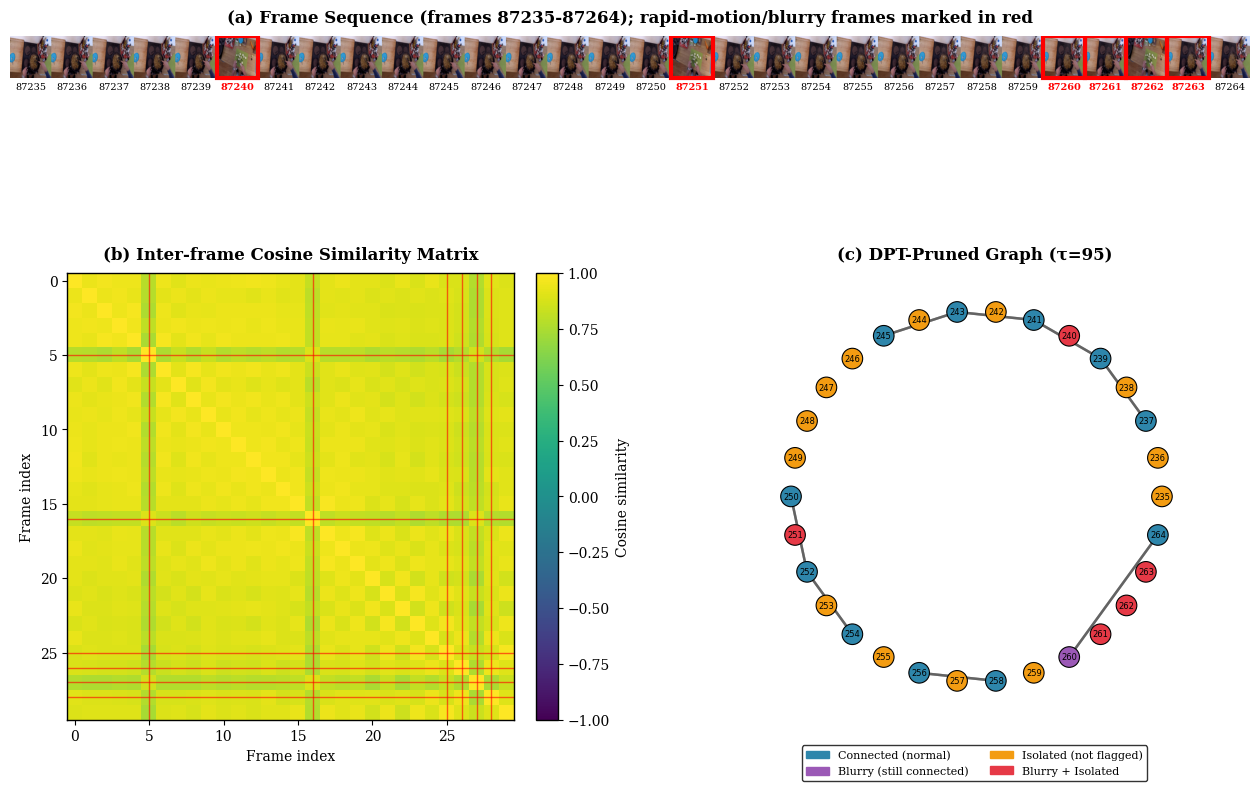


Saved: dpt_blur_visualization.png


In [8]:
# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.size': 10,
#     'axes.linewidth': 1.0,
# })

# fig = plt.figure(figsize=(16, 10))
# gs = GridSpec(2, 2, figure=fig,
#               height_ratios=[1, 2],
#               hspace=0.30, wspace=0.25)

# # === PANEL 1 (top, spans full width): Frame sequence strip ===
# ax1 = fig.add_subplot(gs[0, :])

# # Concatenate thumbnails horizontally for the strip
# strip = np.concatenate(thumbnails, axis=1)
# ax1.imshow(strip)

# # Add red borders around blurry frames
# for bi in blurry_indices:
#     rect = mpatches.Rectangle(
#         (bi * THUMBNAIL_SIZE - 0.5, -0.5),
#         THUMBNAIL_SIZE, THUMBNAIL_SIZE,
#         fill=False, edgecolor='red', linewidth=3
#     )
#     ax1.add_patch(rect)

# # Add frame index labels below thumbnails
# for i, fn in enumerate(selected_frames):
#     ax1.text(i * THUMBNAIL_SIZE + THUMBNAIL_SIZE / 2, THUMBNAIL_SIZE + 8,
#              f"{int(fn)}", ha='center', va='top',
#              fontsize=7,
#              color='red' if i in blurry_indices else 'black',
#              fontweight='bold' if i in blurry_indices else 'normal')

# ax1.set_xlim(-0.5, N * THUMBNAIL_SIZE - 0.5)
# ax1.set_ylim(THUMBNAIL_SIZE + 16, -0.5)
# ax1.set_title(f'(a) Frame Sequence (frames {FRAME_START}-{FRAME_END}); rapid-motion/blurry frames marked in red',
#               fontsize=12, fontweight='bold', pad=10)
# ax1.axis('off')

# # === PANEL 2 (bottom-left): Similarity matrix heatmap ===
# ax2 = fig.add_subplot(gs[1, 0])
# im = ax2.imshow(sim_np, cmap='RdYlBu_r', aspect='equal', vmin=-1, vmax=1)

# # Highlight blurry frames' rows and columns
# for bi in blurry_indices:
#     ax2.axhline(bi, color='red', linewidth=1.0, alpha=0.6)
#     ax2.axvline(bi, color='red', linewidth=1.0, alpha=0.6)

# ax2.set_title('(b) Inter-frame Cosine Similarity Matrix',
#               fontsize=12, fontweight='bold', pad=10)
# ax2.set_xlabel('Frame index', fontsize=10)
# ax2.set_ylabel('Frame index', fontsize=10)
# plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label='Cosine similarity')

# # === PANEL 3 (bottom-right): DPT-pruned graph ===
# ax3 = fig.add_subplot(gs[1, 1])

# # Use circular layout (temporal order)
# pos = nx.circular_layout(G)

# # Node colors: red if isolated OR detected blurry, blue otherwise
# node_colors = []
# for node in range(N):
#     if node in isolated_indices and node in blurry_indices:
#         node_colors.append('#E63946')   # red (both blurry and isolated)
#     elif node in isolated_indices:
#         node_colors.append('#F39C12')   # orange (DPT-isolated but not flagged blurry)
#     elif node in blurry_indices:
#         node_colors.append('#9B59B6')   # purple (flagged blurry but still connected)
#     else:
#         node_colors.append('#2E86AB')   # blue (normal)

# # Draw edges
# nx.draw_networkx_edges(G, pos, ax=ax3, edge_color='#888888',
#                        alpha=0.4, width=0.6, arrows=False)
# # Draw nodes
# nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=node_colors,
#                        node_size=220, edgecolors='black', linewidths=0.8)
# # Label nodes with frame numbers (small font)
# labels = {i: str(int(selected_frames[i]))[-3:] for i in range(N)}
# nx.draw_networkx_labels(G, pos, labels, ax=ax3, font_size=6)

# ax3.set_title(f'(c) DPT-Pruned Graph (τ={DPT_PERCENTILE})',
#               fontsize=12, fontweight='bold', pad=10)
# ax3.set_aspect('equal')
# ax3.axis('off')

# # Legend for panel 3
# legend_handles = [
#     mpatches.Patch(color='#2E86AB', label='Connected (normal)'),
#     mpatches.Patch(color='#9B59B6', label='Blurry (still connected)'),
#     mpatches.Patch(color='#F39C12', label='Isolated (not flagged)'),
#     mpatches.Patch(color='#E63946', label='Blurry + Isolated'),
# ]
# ax3.legend(handles=legend_handles, loc='lower center', ncol=2,
#            fontsize=8, frameon=True, edgecolor='black',
#            bbox_to_anchor=(0.5, -0.15))

# plt.tight_layout()
# plt.savefig(OUTPUT_PNG, dpi=600, bbox_inches='tight', facecolor='white')
# # plt.savefig(OUTPUT_PDF, bbox_inches='tight', facecolor='white')
# plt.show()

# print(f'\nSaved: {OUTPUT_PNG}')
# # print(f'Saved: {OUTPUT_PDF}')


plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.linewidth': 1.0,
})

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig,
              height_ratios=[1, 2],
              hspace=0.30, wspace=0.25)

# === PANEL 1 (top, spans full width): Frame sequence strip ===
ax1 = fig.add_subplot(gs[0, :])

# Concatenate thumbnails horizontally for the strip
strip = np.concatenate(thumbnails, axis=1)
ax1.imshow(strip)

# Add red borders around blurry frames
for bi in blurry_indices:
    rect = mpatches.Rectangle(
        (bi * THUMBNAIL_SIZE - 0.5, -0.5),
        THUMBNAIL_SIZE, THUMBNAIL_SIZE,
        fill=False, edgecolor='red', linewidth=3
    )
    ax1.add_patch(rect)

# Add frame index labels below thumbnails
for i, fn in enumerate(selected_frames):
    ax1.text(i * THUMBNAIL_SIZE + THUMBNAIL_SIZE / 2, THUMBNAIL_SIZE + 8,
             f"{int(fn)}", ha='center', va='top',
             fontsize=7,
             color='red' if i in blurry_indices else 'black',
             fontweight='bold' if i in blurry_indices else 'normal')

ax1.set_xlim(-0.5, N * THUMBNAIL_SIZE - 0.5)
ax1.set_ylim(THUMBNAIL_SIZE + 16, -0.5)
ax1.set_title(f'(a) Frame Sequence (frames {FRAME_START}-{FRAME_END}); rapid-motion/blurry frames marked in red',
              fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# === PANEL 2 (bottom-left): Similarity matrix heatmap ===
ax2 = fig.add_subplot(gs[1, 0])
# Changed colormap to 'viridis' for better perceptual distinction across low/medium/high values
# 'viridis' is perceptually uniform: dark purple (low) -> teal/green (medium) -> yellow (high)
# This makes low and medium similarity values much easier to distinguish
im = ax2.imshow(sim_np, cmap='viridis', aspect='equal', vmin=-1, vmax=1)

# Highlight blurry frames' rows and columns
for bi in blurry_indices:
    ax2.axhline(bi, color='red', linewidth=1.0, alpha=0.6)
    ax2.axvline(bi, color='red', linewidth=1.0, alpha=0.6)

ax2.set_title('(b) Inter-frame Cosine Similarity Matrix',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Frame index', fontsize=10)
ax2.set_ylabel('Frame index', fontsize=10)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label='Cosine similarity')

# === PANEL 3 (bottom-right): DPT-pruned graph ===
ax3 = fig.add_subplot(gs[1, 1])

# Use circular layout (temporal order)
pos = nx.circular_layout(G)

# Node colors: red if isolated OR detected blurry, blue otherwise
node_colors = []
for node in range(N):
    if node in isolated_indices and node in blurry_indices:
        node_colors.append('#E63946')   # red (both blurry and isolated)
    elif node in isolated_indices:
        node_colors.append('#F39C12')   # orange (DPT-isolated but not flagged blurry)
    elif node in blurry_indices:
        node_colors.append('#9B59B6')   # purple (flagged blurry but still connected)
    else:
        node_colors.append('#2E86AB')   # blue (normal)

# Draw edges with BOLDER width and higher opacity for better visibility
nx.draw_networkx_edges(G, pos, ax=ax3, edge_color='#555555',
                       alpha=0.7, width=1.8, arrows=False)
# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=node_colors,
                       node_size=220, edgecolors='black', linewidths=0.8)
# Label nodes with frame numbers (small font)
labels = {i: str(int(selected_frames[i]))[-3:] for i in range(N)}
nx.draw_networkx_labels(G, pos, labels, ax=ax3, font_size=6)

ax3.set_title(f'(c) DPT-Pruned Graph (τ={DPT_PERCENTILE})',
              fontsize=12, fontweight='bold', pad=10)
ax3.set_aspect('equal')
ax3.axis('off')

# Legend for panel 3
legend_handles = [
    mpatches.Patch(color='#2E86AB', label='Connected (normal)'),
    mpatches.Patch(color='#9B59B6', label='Blurry (still connected)'),
    mpatches.Patch(color='#F39C12', label='Isolated (not flagged)'),
    mpatches.Patch(color='#E63946', label='Blurry + Isolated'),
]
ax3.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=8, frameon=True, edgecolor='black',
           bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=600, bbox_inches='tight', facecolor='white')
# plt.savefig(OUTPUT_PDF, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nSaved: {OUTPUT_PNG}')
# print(f'Saved: {OUTPUT_PDF}')

## 8. Summary For Paper / Rebuttal Letter

In [9]:
print("=" * 70)
print("SUMMARY FOR REBUTTAL")
print("=" * 70)
print(f"\nClip: P01_01, frames {FRAME_START}-{FRAME_END} ({N} frames)")
print(f"DPT percentile (τ): {DPT_PERCENTILE}")
print(f"\nFlagged as rapid-motion/blurry: {len(blurry_indices)} frames")
print(f"DPT-isolated: {len(isolated_indices)} frames")
print(f"Overlap (blurry ∩ isolated): {len(overlap)}/{len(blurry_indices)}")

if len(blurry_indices) > 0:
    recall = len(overlap) / len(blurry_indices) * 100
    print(f"\nKey claim: DPT correctly isolates {recall:.0f}% of detected rapid-motion frames,")
    print(f"while the remaining well-connected frames preserve the temporal context needed for GAT.")

SUMMARY FOR REBUTTAL

Clip: P01_01, frames 87235-87264 (30 frames)
DPT percentile (τ): 95

Flagged as rapid-motion/blurry: 6 frames
DPT-isolated: 18 frames
Overlap (blurry ∩ isolated): 5/6

Key claim: DPT correctly isolates 83% of detected rapid-motion frames,
while the remaining well-connected frames preserve the temporal context needed for GAT.
